# Data Quality Analysis: Category Distribution

**Date**: 2025-09-17  
**Purpose**: Comprehensive analysis of category distribution and data quality issues  
**Related**: [child_alone investigation](../docs/sessions/active/2025-09-17-data-quality-child-alone-investigation.md)

## Overview

This notebook analyzes the distribution of all 36 disaster response categories in our training dataset to identify:
- Class imbalance issues
- Categories with insufficient training data
- Data quality concerns

## Key Findings Summary

- **Total Messages**: 26,027 (after ETL processing)
- **Categories with Zero Examples**: 1 (`child_alone`)
- **Most Imbalanced**: `related` (76.48%) vs `offer` (0.45%)
- **Critical Issue**: `child_alone` has degenerate classifier due to zero positive examples

In [16]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

## Data Loading and Category Distribution

In [17]:
from pathlib import Path
import sqlite3
import os

print(f"CWD: {Path.cwd()}")

# Candidate paths for both common notebook CWDs (root vs notebooks/)
candidates = [
    Path("data/02_stg/stg_disaster_response.db"),      # when CWD is project root
    Path("../data/02_stg/stg_disaster_response.db"),   # when CWD is notebooks/
    Path(r"C:\Users\grant\OneDrive\Documents\udacity_data_science_program\05_disaster_response_project\data\02_stg\stg_disaster_response.db"),  # absolute fallback
]

db_path = next((str(p) for p in candidates if p.exists()), None)
print("Resolved DB path:", db_path, "Exists:" if db_path else "Not found")

if not db_path:
    raise FileNotFoundError("Could not locate stg_disaster_response.db from known locations.")

conn = sqlite3.connect(db_path)

CWD: c:\Users\grant\OneDrive\Documents\udacity_data_science_program\05_disaster_response_project
Resolved DB path: data\02_stg\stg_disaster_response.db Exists:


In [18]:
# Get total message count
total_query = 'SELECT COUNT(*) as total FROM stg_disaster_response;'
total_result = pd.read_sql_query(total_query, conn)
total_messages = total_result.iloc[0]['total']

print(f"Total messages in database: {total_messages:,}")

Total messages in database: 26,027


In [19]:
feature_columns = ["message"]
target_columns = ["related",
"request",
    "offer",
    "aid_related",
    "medical_help",
    "medical_products",
    "search_and_rescue",
    "security",
    "military",
    "child_alone",
    "water",
    "food",
    "shelter",
    "clothing",
    "money",
    "missing_people",
    "refugees",
    "death",
    "other_aid",
    "infrastructure_related",
    "transport",
    "buildings",
    "electricity",
    "tools",
    "hospitals",
    "shops",
    "aid_centers",
    "other_infrastructure",
    "weather_related",
    "floods",
    "storm",
    "fire",
    "earthquake",
    "cold",
    "other_weather",
    "direct_report",
]


In [25]:
# Build query to count positive examples for each category
query_parts = []
for col in target_columns:
    query_parts.append(f'SUM({col}) as {col}')

query = f'SELECT {', '.join(query_parts)} FROM stg_disaster_response;'
result = pd.read_sql_query(query, conn)

# Convert to distribution dataframe
distribution_data = []
for col in target_columns:
    count = result.iloc[0][col]
    percentage = (count / total_messages) * 100
    distribution_data.append({
        'category': col,
        'count': count,
        'percentage': percentage
    })

distribution_df = pd.DataFrame(distribution_data)
distribution_df = distribution_df.sort_values('count', ascending=False)
distribution_df

,category,count,percentage
0,related,19906,76.482115
3,aid_related,10860,41.725900
28,weather_related,7297,28.036270
35,direct_report,5075,19.498982
1,request,4474,17.189841
18,other_aid,3446,13.240097
11,food,2923,11.230645
32,earthquake,2455,9.432512
30,storm,2443,9.386406
12,shelter,2314,8.890767


## Critical Data Quality Issues

In [21]:
# Identify categories with zero examples
zero_categories = distribution_df[distribution_df['count'] == 0]['category'].tolist()

print("Categories with ZERO positive examples:")
if zero_categories:
    for cat in zero_categories:
        print(f"  ❌ {cat}")
    print(f"\n⚠️  These categories will have degenerate classifiers!")
else:
    print("  ✅ All categories have at least one positive example")

# Identify very rare categories (< 1%)
rare_categories = distribution_df[distribution_df['percentage'] < 1.0]
print(f"\nCategories with < 1% representation ({len(rare_categories)} total):")
for _, row in rare_categories.iterrows():
    print(f"  🔸 {row['category']:<20} {row['count']:>4} ({row['percentage']:>5.2f}%)")

Categories with ZERO positive examples:
  ❌ child_alone

⚠️  These categories will have degenerate classifiers!

Categories with < 1% representation (4 total):
  🔸 tools                 159 ( 0.61%)
  🔸 shops                 120 ( 0.46%)
  🔸 offer                 118 ( 0.45%)
  🔸 child_alone             0 ( 0.00%)


## Visualization: Category Distribution

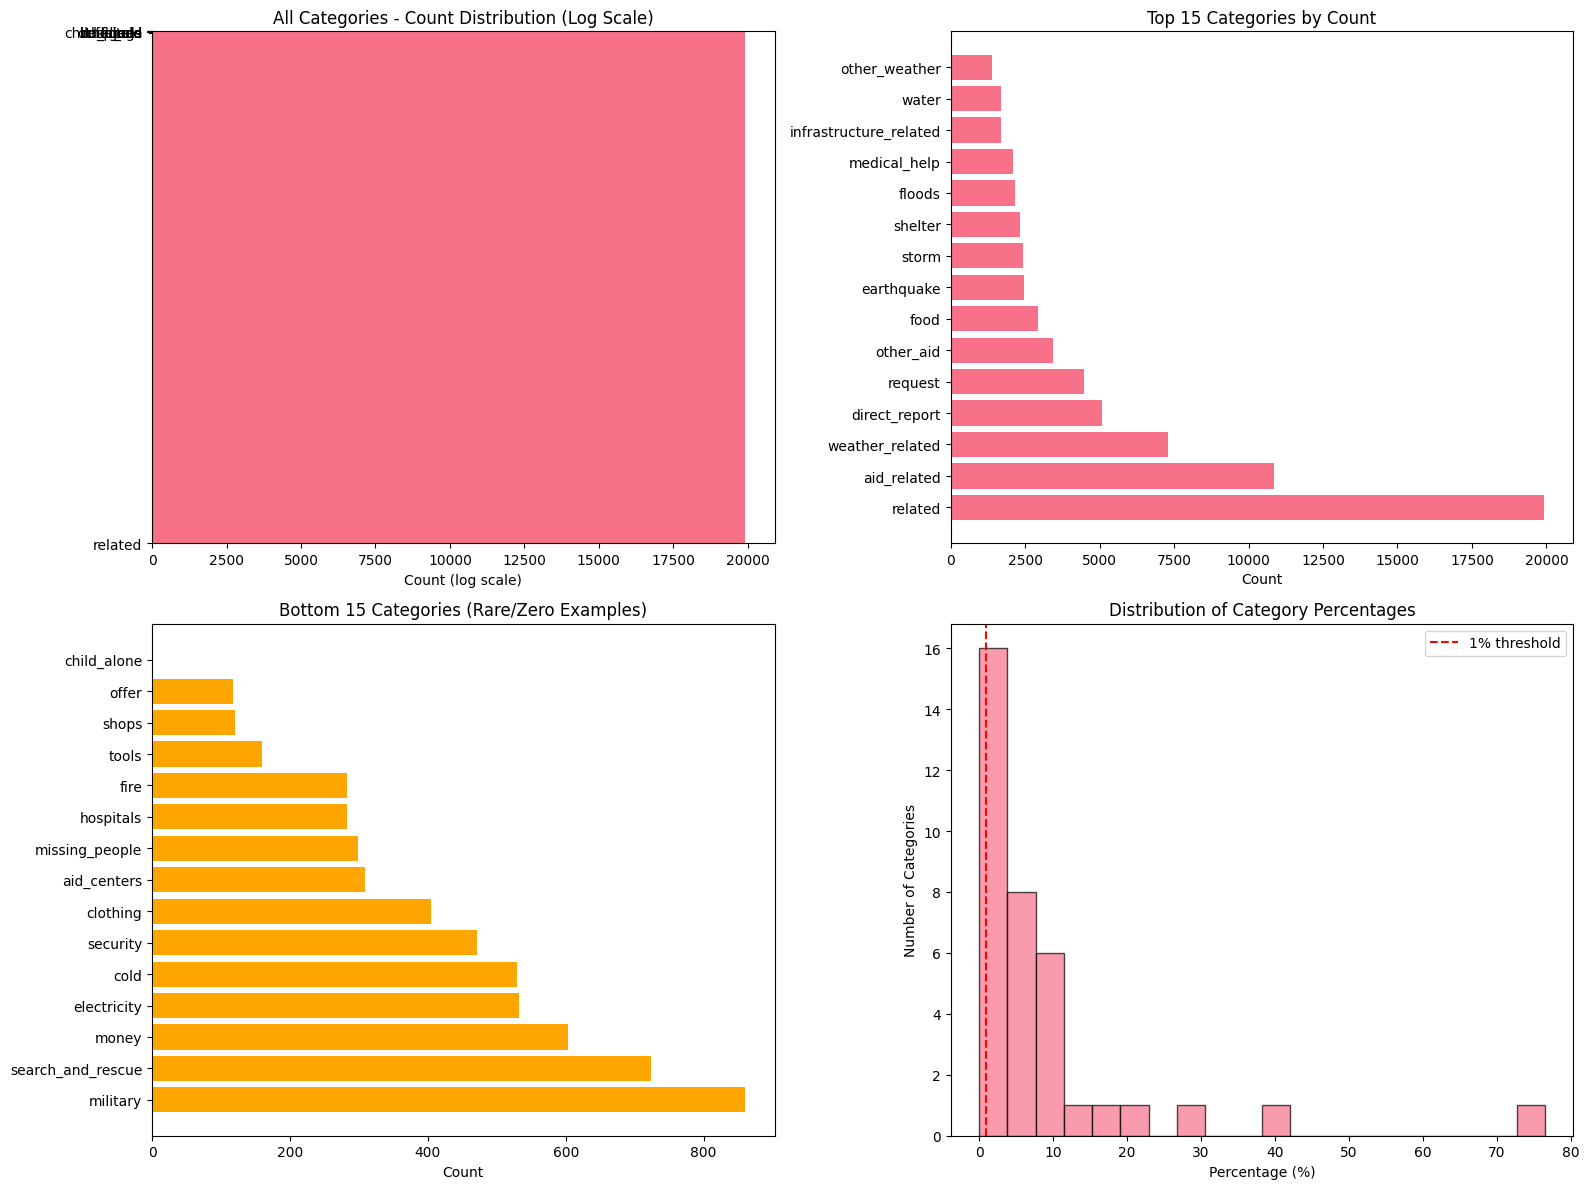

In [22]:
# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Full distribution (log scale)
ax1.barh(range(len(distribution_df)), distribution_df['count'])
ax1.set_yscale('log')
ax1.set_xlabel('Count (log scale)')
ax1.set_title('All Categories - Count Distribution (Log Scale)')
ax1.set_yticks(range(0, len(distribution_df), 5))
ax1.set_yticklabels([distribution_df.iloc[i]['category'] for i in range(0, len(distribution_df), 5)])

# 2. Top 15 categories
top_15 = distribution_df.head(15)
ax2.barh(range(len(top_15)), top_15['count'])
ax2.set_xlabel('Count')
ax2.set_title('Top 15 Categories by Count')
ax2.set_yticks(range(len(top_15)))
ax2.set_yticklabels(top_15['category'])

# 3. Bottom 15 categories (rare)
bottom_15 = distribution_df.tail(15)
colors = ['red' if count == 0 else 'orange' for count in bottom_15['count']]
ax3.barh(range(len(bottom_15)), bottom_15['count'], color=colors)
ax3.set_xlabel('Count')
ax3.set_title('Bottom 15 Categories (Rare/Zero Examples)')
ax3.set_yticks(range(len(bottom_15)))
ax3.set_yticklabels(bottom_15['category'])

# 4. Percentage distribution
ax4.hist(distribution_df['percentage'], bins=20, alpha=0.7, edgecolor='black')
ax4.set_xlabel('Percentage (%)')
ax4.set_ylabel('Number of Categories')
ax4.set_title('Distribution of Category Percentages')
ax4.axvline(x=1.0, color='red', linestyle='--', label='1% threshold')
ax4.legend()

plt.tight_layout()
plt.show()

## Class Imbalance Analysis

In [23]:
# Calculate imbalance metrics
max_count = distribution_df['count'].max()
min_positive_count = distribution_df[distribution_df['count'] > 0]['count'].min()

print("Class Imbalance Metrics:")
print(f"  • Most frequent category: {distribution_df.iloc[0]['category']} ({distribution_df.iloc[0]['count']:,} examples)")
print(f"  • Least frequent category (>0): {distribution_df[distribution_df['count'] > 0].iloc[-1]['category']} ({min_positive_count} examples)")
print(f"  • Imbalance ratio: {max_count / min_positive_count:.1f}:1")
print(f"  • Categories under 1%: {len(rare_categories)} out of {len(target_columns)}")
print(f"  • Categories under 5%: {len(distribution_df[distribution_df['percentage'] < 5.0])} out of {len(target_columns)}")

Class Imbalance Metrics:
  • Most frequent category: related (19,906 examples)
  • Least frequent category (>0): offer (118 examples)
  • Imbalance ratio: 168.7:1
  • Categories under 1%: 4 out of 36
  • Categories under 5%: 19 out of 36
